In [ ]:
import pandas as pd
import numpy as np

In [ ]:
import os

In [ ]:
true=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/FND/True.csv")

In [ ]:
fake = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/FND/Fake.csv")

In [ ]:
fake.tail(10)

,title,text,subject,date
23471,Seven Iranians freed in the prisoner swap have...,"21st Century Wire says This week, the historic...",Middle-east,"January 20, 2016"
23472,#Hashtag Hell & The Fake Left,By Dady Chery and Gilbert MercierAll writers ...,Middle-east,"January 19, 2016"
23473,Astroturfing: Journalist Reveals Brainwashing ...,Vic Bishop Waking TimesOur reality is carefull...,Middle-east,"January 19, 2016"
23474,The New American Century: An Era of Fraud,Paul Craig RobertsIn the last years of the 20t...,Middle-east,"January 19, 2016"
23475,Hillary Clinton: ‘Israel First’ (and no peace ...,Robert Fantina CounterpunchAlthough the United...,Middle-east,"January 18, 2016"
23476,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016"
23477,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016"
23478,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016"
23479,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016"
23480,10 U.S. Navy Sailors Held by Iranian Military ...,21st Century Wire says As 21WIRE predicted in ...,Middle-east,"January 12, 2016"


In [ ]:
fake["subject"].value_counts()

,count
subject,
News,9050
politics,6841
left-news,4459
Government News,1570
US_News,783
Middle-east,778


In [ ]:
true["subject"].value_counts()

,count
subject,
politicsNews,11272
worldnews,10145


In [ ]:
fake["category"]=1
true["category"]=0

In [ ]:
#joining the data of 2 dataframes and reseting index
df=pd.concat([fake,true]).reset_index(drop=True)

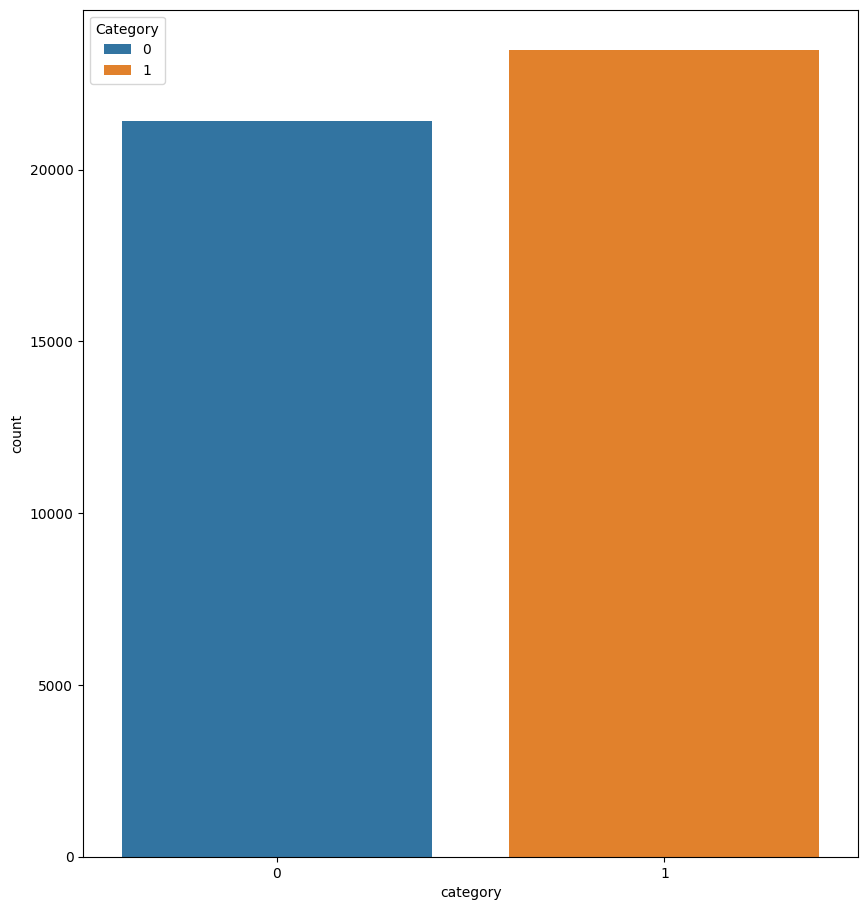

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
#setting the figure size
plt.figure(figsize=(10,11))
# plt.plot(data=df)
sns.countplot(data=df, x="category", hue="category")
plt.legend(title="Category")
plt.show()


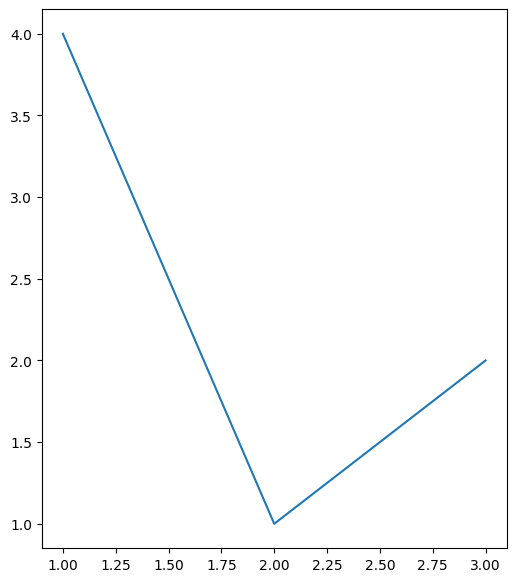

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# Sample data
x = [1, 2, 3]
y = [4, 1, 2]

plt.figure(figsize=(6,7))
# plt.plot(x,y)
sns.lineplot(x=x,y=y)
plt.show()


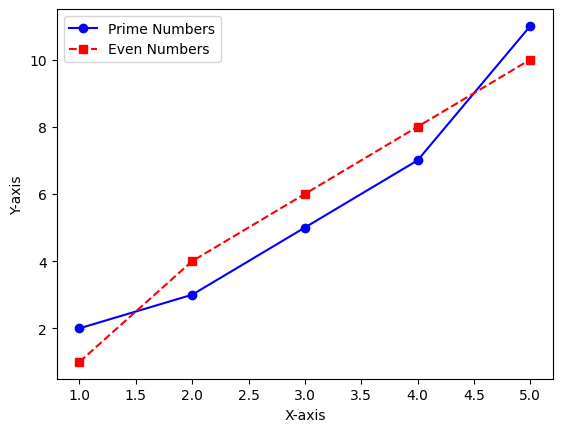

In [ ]:
import matplotlib.pyplot as plt
x = [1, 2, 3, 4, 5]
y1 = [2, 3, 5, 7, 11]
y2 = [1, 4, 6, 8, 10]

plt.plot(x, y1, marker='o', linestyle='-', color='b', label="Prime Numbers")
plt.plot(x, y2, marker='s', linestyle='--', color='r', label="Even Numbers")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.legend()
plt.show()


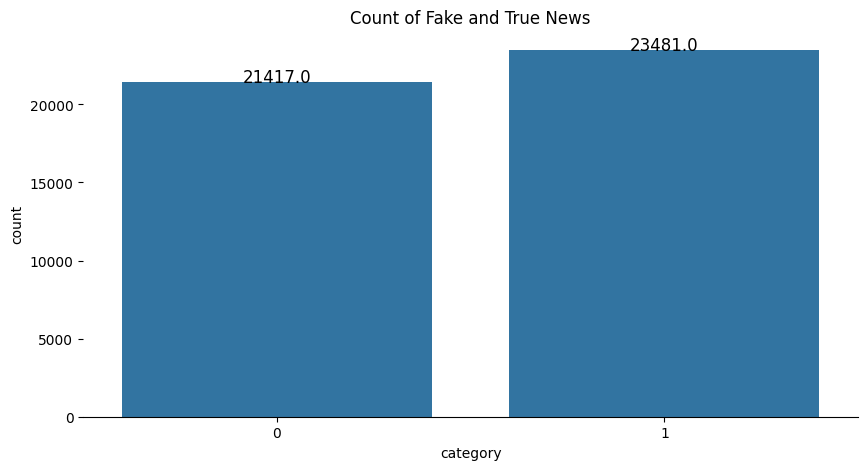

In [ ]:
#creating a count plot for category column
fig = plt.figure(figsize=(10,5))
graph = sns.countplot(x="category", data=df)
plt.title("Count of Fake and True News")

#removing boundary
graph.spines["right"].set_visible(False)
graph.spines["top"].set_visible(False)
graph.spines["left"].set_visible(False)

#annoting bars with the counts
for p in graph.patches:
        height = p.get_height()
        graph.text(p.get_x()+p.get_width()/2., height + 0.2,height ,ha="center",fontsize=12)

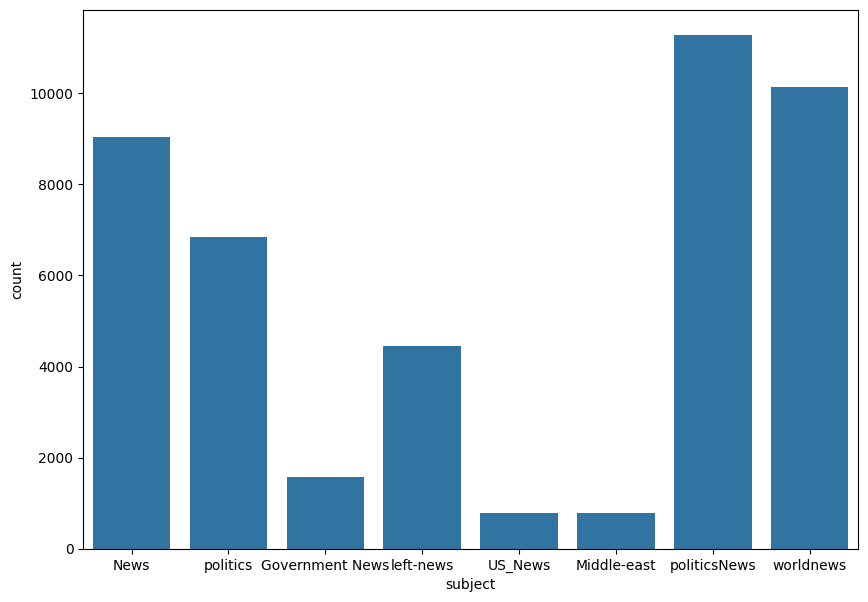

In [ ]:
plt.figure(figsize=(10,7))
sns.countplot(x=df["subject"])  # `x=` is the correct argument
plt.show()

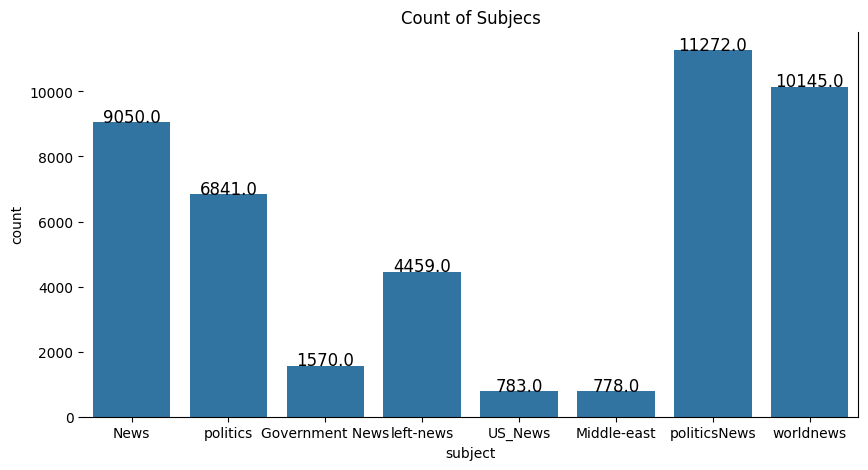

In [ ]:
#creating a count plot for subject column
fig = plt.figure(figsize=(10,5))
graph = sns.countplot(x="subject", data=df)
plt.title("Count of Subjecs")

#removing boundary
graph.spines["right"].set_visible(True)
graph.spines["top"].set_visible(False)
graph.spines["left"].set_visible(False)

#annoting bars with the counts
for p in graph.patches:
        height = p.get_height()
        graph.text(p.get_x()+p.get_width()/2., height + 0.2,height ,ha="center",fontsize=12)

<ipython-input-17-79ce8528071e>:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Subject")  # Now a legend will appear


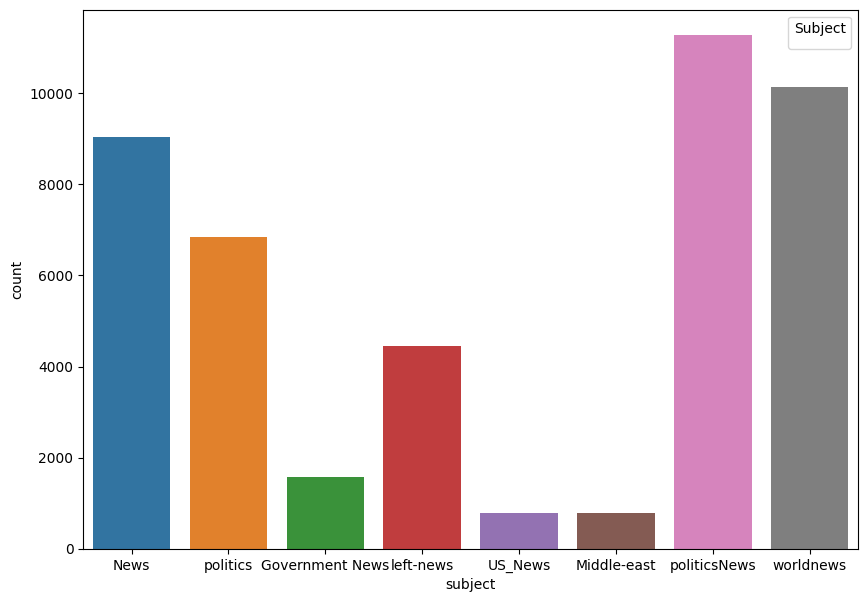

In [ ]:
plt.figure(figsize=(10,7))
sns.countplot(data=df, x="subject", hue="subject")  # hue differentiates categories
plt.legend(title="Subject")  # Now a legend will appear
plt.show()


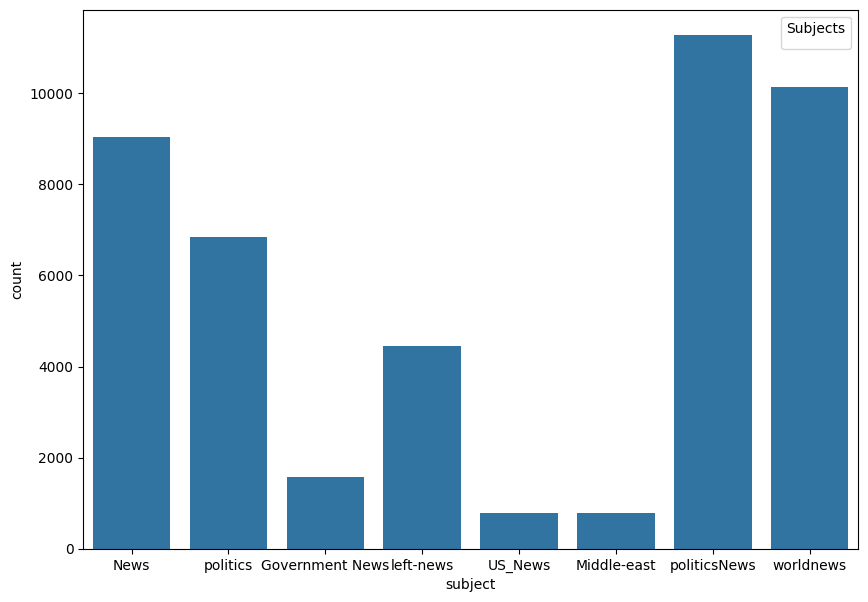

In [ ]:
plt.figure(figsize=(10,7))
ax = sns.countplot(data=df, x="subject")

# Get unique labels and create a legend manually
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles, labels, title="Subjects")

plt.show()

In [ ]:
#instead of dropping these values we are going to merge title with text
df["text"] =df["title"]+df["text"]

#we only need two columns rest can be ignored
df=df[['text','category']]

In [ ]:
df.head()

,text,category
0,Donald Trump Sends Out Embarrassing New Year’...,1
1,Drunk Bragging Trump Staffer Started Russian ...,1
2,Sheriff David Clarke Becomes An Internet Joke...,1
3,Trump Is So Obsessed He Even Has Obama’s Name...,1
4,Pope Francis Just Called Out Donald Trump Dur...,1


Data Cleaning

In [ ]:
df.isna().sum()*100/len(df)

,0
text,0.0
category,0.0


In [ ]:
# blanks = []  # List to store indices of empty string rows

# for index, text in df['text'].iteritems():
#     if isinstance(text, str) and text.isspace():  # Check if text is a string before calling isspace()
#         blanks.append(index)

# print(f"Number of empty string rows: {len(blanks)}")
blanks = df[df['text'].str.isspace()].index.tolist()
print(f"Number of empty string rows: {len(blanks)}")


Number of empty string rows: 0


In [ ]:
blanks

[]

In [ ]:
df['text'][10923]

'TAKE OUR POLL: Who Do You Think President Trump Should Pick To Replace James Comey? '

In [ ]:
df[df['text'].str.isspace()]

,text,category


In [ ]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import spacy
import re
import nltk
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
#loading spacy library
nlp=spacy.load("en_core_web_sm")

#creating instance
lemma=WordNetLemmatizer()

In [ ]:
#creating list of stopwords containing stopwords from spacy and nltk

#stopwords of spacy
list1=nlp.Defaults.stop_words
print(len(list1))

#stopwords of NLTK
list2=stopwords.words('english')
print(len(list2))

#combining the stopword list
Stopwords=set((set(list1)|set(list2)))
print(len(Stopwords))

326
198
401


In [ ]:
#text cleaning function
def clean_text(text):

    """
    It takes text as an input and clean it by applying several methods

    """

    string = ""

    #lower casing
    text=text.lower()

    #simplifying text
    text=re.sub(r"i'm","i am",text)
    text=re.sub(r"he's","he is",text)
    text=re.sub(r"she's","she is",text)
    text=re.sub(r"that's","that is",text)
    text=re.sub(r"what's","what is",text)
    text=re.sub(r"where's","where is",text)
    text=re.sub(r"\'ll"," will",text)
    text=re.sub(r"\'ve"," have",text)
    text=re.sub(r"\'re"," are",text)
    text=re.sub(r"\'d"," would",text)
    text=re.sub(r"won't","will not",text)
    text=re.sub(r"can't","cannot",text)

    #removing any special character
    text=re.sub(r"[-()\"#!@$%^&*{}?.,:]"," ",text)
    text=re.sub(r"\s+"," ",text)
    text=re.sub('[^A-Za-z0-9]+',' ', text)

    for word in text.split():
        if word not in Stopwords:
            string+=lemma.lemmatize(word)+" "

    return string

In [ ]:
#cleaning the whole data
df["text"]=df["text"].apply(clean_text)

In [ ]:
from wordcloud import WordCloud

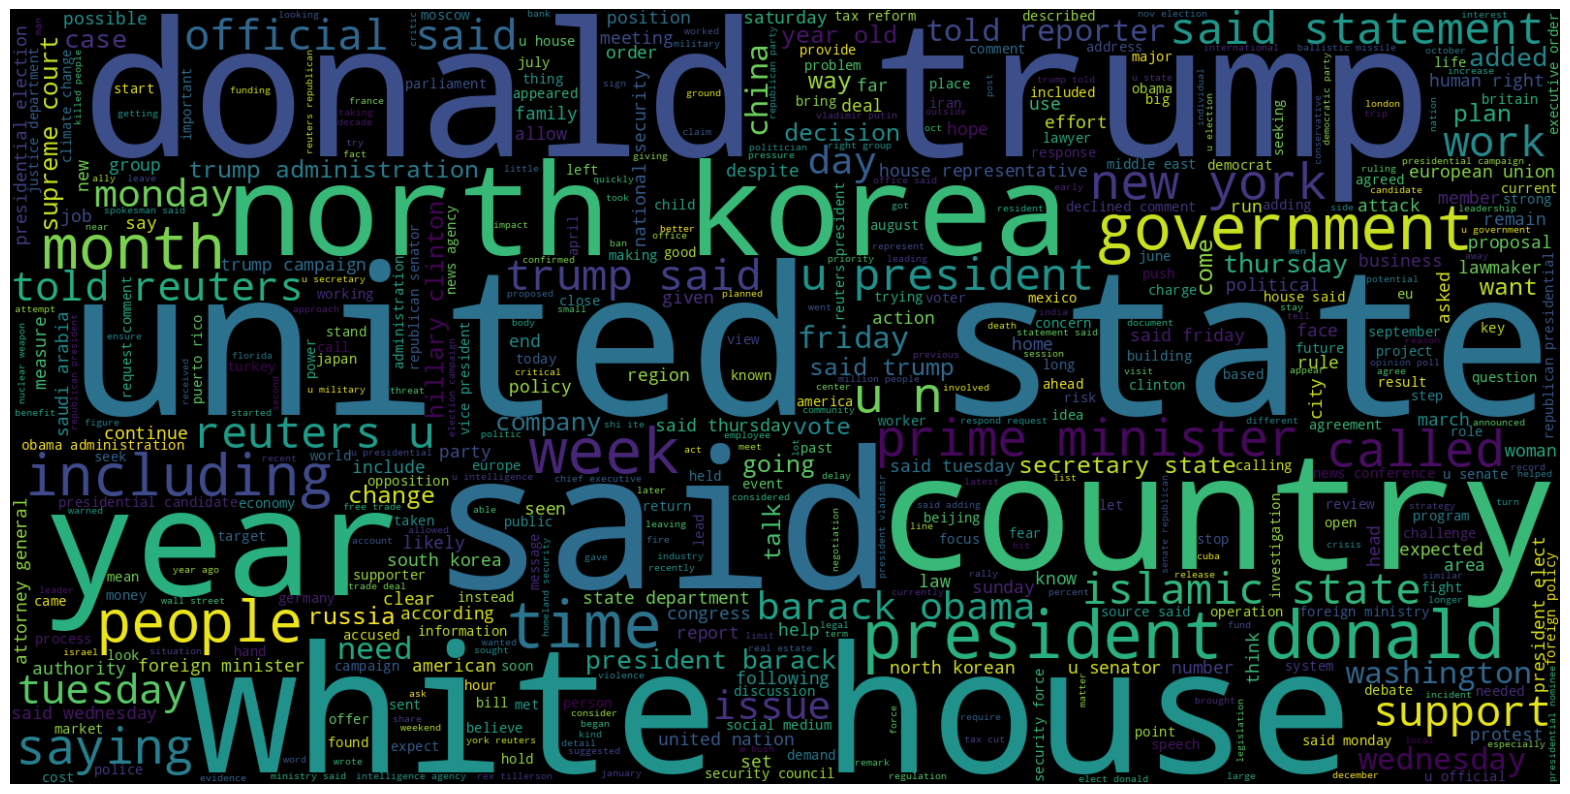

In [ ]:
#True News
plt.figure(figsize = (20,20))
Wc = WordCloud(max_words = 500 , width = 1600 , height = 800).generate(" ".join(df[df.category == 0].text))
plt.axis("off")
plt.imshow(Wc , interpolation = 'bilinear')

In [ ]:
#creating more intiuive wordcloud

#pil is pillow and used for image manupulation
from PIL import Image

In [ ]:
#creating word cloud using skull image for fake news which depict that
#fake news are dangerous

skull="/content/drive/MyDrive/Colab Notebooks/FND/skull-icon.png"
icon=Image.open(skull)
mask=Image.new(mode="RGB",size=icon.size, color=(255,255,255))
mask.paste(icon, box=icon)

rgb_array=np.array(mask)

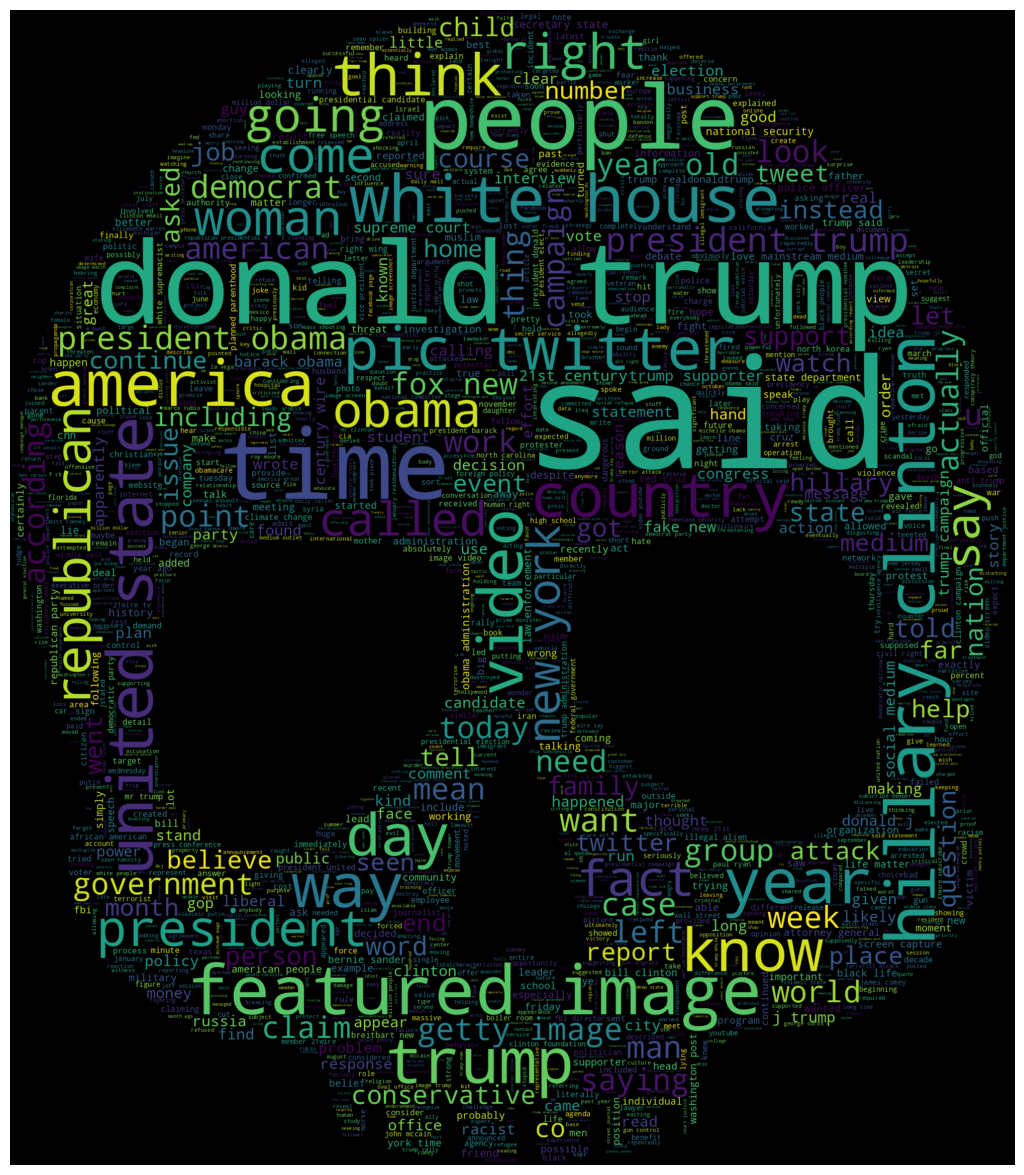

In [ ]:
#Fake News
plt.figure(figsize = (15,15))
Wc = WordCloud(mask=rgb_array,max_words = 2000 , width = 1600 ,
               height = 800)

Wc.generate(" ".join(df[df.category == 1].text))
plt.axis("off")
plt.imshow(Wc , interpolation = 'bilinear')

Feature-Extraction & Model building

In [ ]:
from sklearn.model_selection import train_test_split

# Assuming df has 'text' column for input and 'category' column for labels
X = df["text"]  # Features (text data)
y = df["category"]  # Labels

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data successfully split!")


Data successfully split!


In [ ]:
# #splitting the
# from sklearn.model_selection import train_test_split


# X=df["text"] #feature
# y=df["category"] # traget

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [ ]:
#importing libraries to build a pipline
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

In [ ]:
X_train = X_train.astype(str)


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

# Define pipeline
text_clf = Pipeline([
    ("tfidf", TfidfVectorizer()),  # Convert text to TF-IDF vectors
    ("clf", LinearSVC())  # Train a classifier
])

# Fit the model
text_clf.fit(X_train.astype(str), y_train)

# Check if the model was trained successfully
print("Model trained successfully!")


Model trained successfully!


In [ ]:
print(X_train.shape, y_train.shape)  # Check dimensions
print(type(X_train), type(y_train))  # Check data types


(35918,) (35918,)
<class 'pandas.core.series.Series'> <class 'pandas.core.series.Series'>


In [ ]:
#this pipe line will take the text and vectorise it , and then TF-IDF, then fitting the model

text_clf=Pipeline([("tfidf",TfidfVectorizer()),("clf",LinearSVC())])
text_clf.fit(X_train,y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer()), ('clf', LinearSVC())])

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

text_clf = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', MultinomialNB())
])
3

In [ ]:
#making prediction using the model
predictions=text_clf.predict(X_test)

In [ ]:
from sklearn import metrics
print(metrics.classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4247
           1       0.99      1.00      1.00      4733

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



In [ ]:
#overall acuracy
print(metrics.accuracy_score(y_test,predictions))

0.9948775055679288


In [ ]:
#confusion matrix
print(metrics.confusion_matrix(y_test,predictions))

[[4223   24]
 [  22 4711]]


In [ ]:
import joblib
joblib.dump(text_clf, "fake_news_model.pkl")


['fake_news_model.pkl']